# 2026-02-11 ~ 2026-05-11 주 단위 모터 개폐율·습도 연관도 분석

## 분석 목표

이 노트북은 기존 `data_inspect_260211-260511_C.ipynb`와 같은 데이터 범위와 주 단위 선택 방식을 사용하되, 분석 초점을 **습도와 모터 개폐율의 연관도**에 둔다.

함께 보는 습도 데이터는 다음과 같다.

- 내부 온습도 센서의 `humi`
- 외부 온습도 센서의 `humi`
- 내부-외부 습도차
- 기상청 데이터 `HM`

모터 개폐율은 평균으로 합치지 않고, 각 모터 채널의 `open_rate`를 개별적으로 분석한다.

## 0. 해석 관점

습도와 개폐율의 관계는 단순한 동시 상관만으로 판단하기 어렵다. 예를 들어 외부 습도가 높아질 때 개폐율이 낮아지는 현상이 보이더라도, 실제로는 강우, 일사, 온도, 운영 정책이 동시에 작용했을 수 있다.

따라서 이 노트북은 다음 관점을 함께 본다.

- 같은 시간대의 습도와 개별 채널 개폐율 상관관계
- 습도가 먼저 변하고 개폐율이 뒤따르는지 확인하는 lag 상관관계
- 하루 단위로 습도 최고/최저, 습도차, 강우 감지, 개폐율 peak를 함께 요약
- 선택한 주의 시간 흐름에서 채널별 개폐율과 습도 변화가 어떻게 겹치는지 시각화

In [19]:
from __future__ import annotations

import re
from pathlib import Path
from typing import Dict, List, Optional, Tuple

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, clear_output, display

ANALYSIS_START = "2026-02-11 00:00:00"
ANALYSIS_END = "2026-05-11 17:00:00"
ANALYSIS_TIMEZONE = "Asia/Seoul"
RESAMPLE_RULE = "1h"

current = Path.cwd().resolve()
PROJECT_ROOT = next(
    path
    for path in [current, *current.parents]
    if (path / "pipeline_output" / "organized_by_sensor").exists()
)
ORGANIZED_SENSOR_ROOT = PROJECT_ROOT / "pipeline_output" / "organized_by_sensor"
KMA_CSV_ROOT = PROJECT_ROOT / "pipeline_output" / "kma_data" / "csv"
OUTPUT_ROOT = PROJECT_ROOT / "data_inspect" / "output" / "weekly_motor_humidity_analysis_260211-260511"
PLOT_ROOT = OUTPUT_ROOT / "plots"
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)
PLOT_ROOT.mkdir(parents=True, exist_ok=True)

ANALYSIS_START_TS = pd.Timestamp(ANALYSIS_START, tz="UTC")
ANALYSIS_END_TS = pd.Timestamp(ANALYSIS_END, tz="UTC")
ANALYSIS_START_LOCAL = ANALYSIS_START_TS.tz_convert(ANALYSIS_TIMEZONE)
ANALYSIS_END_LOCAL = ANALYSIS_END_TS.tz_convert(ANALYSIS_TIMEZONE)

plt.rcParams["figure.figsize"] = (15, 6)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25
plt.rcParams["axes.unicode_minus"] = False
for font_name in ["AppleGothic", "Malgun Gothic", "NanumGothic", "DejaVu Sans"]:
    try:
        plt.rcParams["font.family"] = font_name
        break
    except Exception:
        pass

print(f"PROJECT_ROOT = {PROJECT_ROOT}")
print(f"ORGANIZED_SENSOR_ROOT = {ORGANIZED_SENSOR_ROOT}")
print(f"KMA_CSV_ROOT = {KMA_CSV_ROOT}")
print(f"OUTPUT_ROOT = {OUTPUT_ROOT}")

PROJECT_ROOT = /Users/jeong-won-il/workspace/SDF/train
ORGANIZED_SENSOR_ROOT = /Users/jeong-won-il/workspace/SDF/train/pipeline_output/organized_by_sensor
KMA_CSV_ROOT = /Users/jeong-won-il/workspace/SDF/train/pipeline_output/kma_data/csv
OUTPUT_ROOT = /Users/jeong-won-il/workspace/SDF/train/data_inspect/output/weekly_motor_humidity_analysis_260211-260511


## 1. 주 선택 설정

아래 변수만 바꾸면 분석 대상 주를 변경할 수 있다.

- `SELECTED_WEEK_INDEX`: 주 목록의 번호로 선택
- `SELECTED_WEEK_START_DATE`: 특정 날짜 직접 지정. `None`이면 `SELECTED_WEEK_INDEX` 사용
- `LAG_HOURS`: 습도 시차상관 후보. 음수는 습도 변화가 개폐율보다 먼저 나타나는 경우를 의미한다.

In [20]:
SELECTED_WEEK_INDEX = 10
SELECTED_WEEK_START_DATE = None
SAVE_WEEK_OUTPUTS = True
SHOW_ALL_CHANNEL_LEGEND = True
LAG_HOURS = [-24, -12, -6, -3, -1, 0, 1, 3, 6, 12, 24]

## 2. 데이터 로드 함수

센서 CSV는 `pipeline_output/organized_by_sensor`에서 읽고, 기상청 CSV는 `pipeline_output/kma_data/csv`에서 읽는다.

- 내부/외부 온습도 센서: `temp`, `humi`
- 모터 센서: `open_rate`
- 우적 센서: `rain`
- 기상청: `HM`, `RN`, `TA`

In [21]:
def parse_datetime_column(series: pd.Series) -> pd.Series:
    try:
        return pd.to_datetime(series, errors="coerce", utc=True, format="mixed")
    except (TypeError, ValueError):
        return pd.to_datetime(series, errors="coerce", utc=True)


def classify_data_kind(path: Path, columns: List[str]) -> str:
    column_set = set(columns)
    if "open_rate" in column_set:
        return "motor_open_rate"
    if {"temp", "humi"}.issubset(column_set):
        return "internal_environment" if path.name.startswith("In_") else "external_environment"
    if "rain" in column_set:
        return "external_rain"
    return "other"


def short_id(value: object) -> str:
    if pd.isna(value):
        return "none"
    text = str(value).strip()
    return text[:8] if text else "none"


def safe_filename(text: str) -> str:
    safe = re.sub(r"\s+", "_", str(text).strip())
    safe = re.sub(r"[^0-9A-Za-z가-힣_\-]+", "_", safe)
    return re.sub(r"_+", "_", safe).strip("_")[:120]


def build_sensor_label(path: Path, frame: pd.DataFrame, data_kind: str) -> str:
    sensor_group = path.parent.name
    sensor_id = "unknown"
    if "sensor_id" in frame.columns and frame["sensor_id"].notna().any():
        sensor_id = short_id(frame["sensor_id"].dropna().iloc[0])

    if data_kind == "motor_open_rate":
        probe = None
        if "probe" in frame.columns and frame["probe"].notna().any():
            probe = str(frame["probe"].dropna().iloc[0])
        if probe is None:
            match = re.search(r"_ch(\d+)_", path.name)
            probe = match.group(1) if match else "unknown"
        return f"{sensor_group} | {sensor_id} | ch{probe}"

    if data_kind == "external_rain":
        return f"{sensor_group} | rain | {sensor_id}"

    if data_kind in {"internal_environment", "external_environment"}:
        direction = "In" if data_kind == "internal_environment" else "Out"
        return f"{sensor_group} | {direction} | {sensor_id}"

    return f"{sensor_group} | {sensor_id}"


def discover_sensor_files(root: Path) -> List[Path]:
    return sorted(
        path
        for path in root.rglob("*.csv")
        if path.name != "organizing_summary.csv" and not path.name.startswith(".")
    )


def load_sensor_frame(path: Path) -> Optional[Dict[str, object]]:
    try:
        frame = pd.read_csv(path)
    except Exception as exc:
        print(f"파일 읽기 실패: {path} ({exc})")
        return None

    frame.columns = [str(column).strip() for column in frame.columns]
    if "ts" not in frame.columns:
        return None

    frame["ts"] = parse_datetime_column(frame["ts"])
    if "created_at" in frame.columns:
        frame["created_at"] = parse_datetime_column(frame["created_at"])

    data_kind = classify_data_kind(path, list(frame.columns))
    frame = frame[frame["ts"].between(ANALYSIS_START_TS, ANALYSIS_END_TS)].copy()
    if frame.empty:
        return None

    sensor_label = build_sensor_label(path, frame, data_kind)
    frame["local_ts"] = frame["ts"].dt.tz_convert(ANALYSIS_TIMEZONE)
    frame["date"] = frame["local_ts"].dt.date
    frame["hour"] = frame["local_ts"].dt.hour
    frame["source_file"] = str(path.relative_to(PROJECT_ROOT))
    frame["sensor_group"] = path.parent.name
    frame["sensor_label"] = sensor_label
    frame["data_kind"] = data_kind

    return {
        "path": path,
        "relative_path": str(path.relative_to(PROJECT_ROOT)),
        "sensor_group": path.parent.name,
        "sensor_label": sensor_label,
        "data_kind": data_kind,
        "frame": frame,
    }


def pick_kma_csv_path(root: Path) -> Optional[Path]:
    preferred = root / "kma_181_20260211_20260511.csv"
    if preferred.exists():
        return preferred
    files = sorted(root.glob("kma_*.csv"))
    return files[0] if files else None


def load_kma_frame(root: Path) -> pd.DataFrame:
    preferred = pick_kma_csv_path(root)
    if preferred is None:
        return pd.DataFrame(columns=["local_ts", "kma_humidity"])

    if preferred.name == "kma_181_20260211_20260511.csv":
        raw = pd.read_csv(preferred)
    else:
        raw = pd.concat([pd.read_csv(path) for path in sorted(root.glob("kma_*.csv"))], ignore_index=True)

    raw.columns = [str(column).strip() for column in raw.columns]
    if "YYMMDDHHMI" not in raw.columns:
        return pd.DataFrame(columns=["local_ts", "kma_humidity"])

    kma = raw.copy()
    timestamp_text = kma["YYMMDDHHMI"].astype(str).str.replace(r"\.0$", "", regex=True).str.zfill(12)
    kma["local_ts"] = pd.to_datetime(timestamp_text, format="%Y%m%d%H%M", errors="coerce").dt.tz_localize(ANALYSIS_TIMEZONE)
    kma = kma[kma["local_ts"].between(ANALYSIS_START_LOCAL, ANALYSIS_END_LOCAL)].copy()

    for source, target in {"HM": "kma_humidity", "RN": "kma_rainfall", "TA": "kma_air_temperature"}.items():
        if source in kma.columns:
            kma[target] = pd.to_numeric(kma[source], errors="coerce")
        else:
            kma[target] = np.nan

    kma.loc[kma["kma_humidity"] < 0, "kma_humidity"] = np.nan
    kma.loc[kma["kma_rainfall"] < 0, "kma_rainfall"] = 0
    kma.loc[kma["kma_air_temperature"] <= -90, "kma_air_temperature"] = np.nan

    keep_columns = ["local_ts", "kma_humidity", "kma_rainfall", "kma_air_temperature"]
    return kma[keep_columns].dropna(subset=["local_ts"]).drop_duplicates(subset=["local_ts"], keep="last").sort_values("local_ts")

## 3. 전체 데이터 로드와 시간 정렬

모든 데이터를 1시간 단위로 정렬한다.

- 모터 개폐율: 채널별 1시간 중앙값
- 습도: 내부/외부 센서별 1시간 중앙값 후 scope 평균
- 온도: 습도 해석 보조 변수
- 강우: 습도 상승과 함께 해석하기 위한 보조 변수
- KMA 습도: 외부 기상 관측 습도

In [22]:
sensor_files = discover_sensor_files(ORGANIZED_SENSOR_ROOT)
records = [record for path in sensor_files if (record := load_sensor_frame(path)) is not None]
kma_hourly = load_kma_frame(KMA_CSV_ROOT)

file_overview = pd.DataFrame(
    [
        {
            "sensor_label": record["sensor_label"],
            "data_kind": record["data_kind"],
            "rows": len(record["frame"]),
            "source_file": record["relative_path"],
        }
        for record in records
    ]
)

display(file_overview.groupby("data_kind")["rows"].agg(["count", "sum"]).reset_index())
display(file_overview)
print(f"KMA rows: {len(kma_hourly):,}")
display(kma_hourly.head())

,data_kind,count,sum
0,external_environment,1,87242
1,external_rain,1,87245
2,internal_environment,2,175663
3,motor_open_rate,16,2344192
4,other,1,87260


,sensor_label,data_kind,rows,source_file
0,AGS Green 단동 7동 모터 제어 모듈 | bd7d3355 | ch1,motor_open_rate,146549,pipeline_output/organized_by_sensor/AGS Green ...
1,AGS Green 단동 7동 모터 제어 모듈 | bd7d3355 | ch2,motor_open_rate,146549,pipeline_output/organized_by_sensor/AGS Green ...
2,AGS Green 단동 7동 모터 제어 모듈 | bd7d3355 | ch3,motor_open_rate,146549,pipeline_output/organized_by_sensor/AGS Green ...
3,AGS Green 단동 7동 모터 제어 모듈 | bd7d3355 | ch4,motor_open_rate,146549,pipeline_output/organized_by_sensor/AGS Green ...
4,AGS Green 단동 7동 모터 제어 모듈 | bd7d3355 | ch5,motor_open_rate,146549,pipeline_output/organized_by_sensor/AGS Green ...
5,AGS Green 단동 7동 모터 제어 모듈 | bd7d3355 | ch6,motor_open_rate,146549,pipeline_output/organized_by_sensor/AGS Green ...
6,AGS Green 단동 7동 모터 제어 모듈 | bd7d3355 | ch7,motor_open_rate,146549,pipeline_output/organized_by_sensor/AGS Green ...
7,AGS Green 단동 7동 모터 제어 모듈 | bd7d3355 | ch8,motor_open_rate,146549,pipeline_output/organized_by_sensor/AGS Green ...
8,AGS Green 단동 7동 온습도 센서 | In | c03b3850,internal_environment,87808,pipeline_output/organized_by_sensor/AGS Green ...
9,AGS Green 단동 8동 모터 제어 모듈 | 95ccaf9b | ch1,motor_open_rate,146475,pipeline_output/organized_by_sensor/AGS Green ...


KMA rows: 2,145


,local_ts,kma_humidity,kma_rainfall,kma_air_temperature
9,2026-02-11 09:00:00+09:00,89.0,0.0,1.7
10,2026-02-11 10:00:00+09:00,89.0,0.0,2.1
11,2026-02-11 11:00:00+09:00,84.0,0.0,3.1
12,2026-02-11 12:00:00+09:00,73.0,0.0,4.7
13,2026-02-11 13:00:00+09:00,71.0,0.0,4.7


In [23]:
def build_motor_open_rate_hourly(records: List[Dict[str, object]]) -> pd.DataFrame:
    series_map = {}
    for record in records:
        if record["data_kind"] != "motor_open_rate":
            continue
        frame = record["frame"]
        if frame.empty or "open_rate" not in frame.columns:
            continue
        values = frame[["local_ts", "open_rate"]].copy()
        values["open_rate"] = pd.to_numeric(values["open_rate"], errors="coerce")
        values = values.dropna(subset=["local_ts", "open_rate"]).sort_values("local_ts")
        values = values.drop_duplicates(subset=["local_ts"], keep="last")
        series_map[record["sensor_label"]] = values.set_index("local_ts")["open_rate"].resample(RESAMPLE_RULE).median()
    return pd.concat(series_map, axis=1).sort_index() if series_map else pd.DataFrame()


def build_environment_hourly(records: List[Dict[str, object]], value_column: str, output_prefix: str) -> Tuple[pd.DataFrame, pd.DataFrame]:
    long_frames = []
    for record in records:
        if record["data_kind"] not in {"internal_environment", "external_environment"}:
            continue
        frame = record["frame"]
        if frame.empty or value_column not in frame.columns:
            continue
        values = frame[["local_ts", value_column]].copy()
        values[value_column] = pd.to_numeric(values[value_column], errors="coerce")
        values = values.dropna(subset=["local_ts", value_column]).sort_values("local_ts")
        values = values.drop_duplicates(subset=["local_ts"], keep="last")
        series = values.set_index("local_ts")[value_column].resample(RESAMPLE_RULE).median()
        scope = "internal" if record["data_kind"] == "internal_environment" else "external"
        long_frames.append(
            pd.DataFrame(
                {
                    "local_ts": series.index,
                    output_prefix: series.values,
                    "scope": scope,
                    "sensor_label": record["sensor_label"],
                }
            )
        )

    if not long_frames:
        return pd.DataFrame(), pd.DataFrame()

    long = pd.concat(long_frames, ignore_index=True).dropna(subset=[output_prefix])
    wide = long.groupby(["local_ts", "scope"])[output_prefix].mean().unstack("scope").sort_index()
    wide = wide.rename(columns={"internal": f"internal_{output_prefix}", "external": f"external_{output_prefix}"})
    if f"internal_{output_prefix}" in wide.columns and f"external_{output_prefix}" in wide.columns:
        wide[f"{output_prefix}_gap"] = wide[f"internal_{output_prefix}"] - wide[f"external_{output_prefix}"]
    return wide, long


def build_rain_hourly(records: List[Dict[str, object]]) -> pd.DataFrame:
    rain_frames = []
    for record in records:
        if record["data_kind"] != "external_rain":
            continue
        frame = record["frame"]
        if frame.empty or "rain" not in frame.columns:
            continue
        values = frame[["local_ts", "rain"]].copy()
        values["rain"] = pd.to_numeric(values["rain"], errors="coerce")
        values = values.dropna(subset=["local_ts", "rain"]).sort_values("local_ts")
        values = values.drop_duplicates(subset=["local_ts"], keep="last")
        rain_frames.append(values.set_index("local_ts")["rain"].resample(RESAMPLE_RULE).max())
    if not rain_frames:
        return pd.DataFrame(columns=["rain_sensor_value", "rain_sensor_flag"])
    rain = pd.concat(rain_frames, axis=1).max(axis=1).to_frame("rain_sensor_value")
    rain["rain_sensor_flag"] = (rain["rain_sensor_value"] > 0).astype(int)
    return rain.sort_index()


motor_hourly = build_motor_open_rate_hourly(records)
humidity_hourly, humidity_long = build_environment_hourly(records, "humi", "humidity")
temperature_hourly, temperature_long = build_environment_hourly(records, "temp", "temp")
rain_hourly = build_rain_hourly(records)
kma_indexed = kma_hourly.set_index("local_ts").sort_index() if not kma_hourly.empty else pd.DataFrame()

aligned_hourly = pd.concat([motor_hourly, humidity_hourly, temperature_hourly, rain_hourly, kma_indexed], axis=1).sort_index()
aligned_hourly = aligned_hourly[(aligned_hourly.index >= ANALYSIS_START_LOCAL) & (aligned_hourly.index <= ANALYSIS_END_LOCAL)]
aligned_hourly["date"] = aligned_hourly.index.date
aligned_hourly["hour"] = aligned_hourly.index.hour
WEEK_ANCHOR = ANALYSIS_START_LOCAL.floor("D")
week_offsets = ((aligned_hourly.index - WEEK_ANCHOR) // pd.Timedelta(days=7)).astype(int)
aligned_hourly["week_start"] = WEEK_ANCHOR + pd.to_timedelta(week_offsets * 7, unit="D")

motor_columns = list(motor_hourly.columns)
humidity_columns = [
    column
    for column in ["internal_humidity", "external_humidity", "humidity_gap", "kma_humidity"]
    if column in aligned_hourly.columns
]
context_columns = [
    column
    for column in ["internal_temp", "external_temp", "temp_gap", "rain_sensor_value", "rain_sensor_flag", "kma_rainfall", "kma_air_temperature"]
    if column in aligned_hourly.columns
]

aligned_hourly.to_csv(OUTPUT_ROOT / "aligned_hourly_humidity.csv", encoding="utf-8-sig")
humidity_long.to_csv(OUTPUT_ROOT / "humidity_hourly_long.csv", index=False, encoding="utf-8-sig")

print(f"motor channels: {len(motor_columns)}")
print(f"humidity variables: {humidity_columns}")
print(f"aligned_hourly rows: {len(aligned_hourly):,}")
display(aligned_hourly[motor_columns[:3] + humidity_columns + context_columns[:3]].head())

motor channels: 16
humidity variables: ['internal_humidity', 'external_humidity', 'humidity_gap', 'kma_humidity']
aligned_hourly rows: 2,153


,AGS Green 단동 7동 모터 제어 모듈 | bd7d3355 | ch1,AGS Green 단동 7동 모터 제어 모듈 | bd7d3355 | ch2,AGS Green 단동 7동 모터 제어 모듈 | bd7d3355 | ch3,internal_humidity,external_humidity,humidity_gap,kma_humidity,internal_temp,external_temp,temp_gap
local_ts,,,,,,,,,,
2026-02-11 09:00:00+09:00,0.0,0.0,0.0,85.850,29.5,56.350,89.0,10.00,1.80,8.20
2026-02-11 10:00:00+09:00,0.0,0.0,0.0,83.650,31.0,52.650,89.0,11.45,3.00,8.45
2026-02-11 11:00:00+09:00,0.0,0.0,0.0,77.450,29.5,47.950,84.0,15.30,5.15,10.15
2026-02-11 12:00:00+09:00,0.0,0.0,0.0,65.200,27.0,38.200,73.0,23.85,6.20,17.65
2026-02-11 13:00:00+09:00,0.0,0.0,0.0,70.625,27.0,43.625,71.0,21.20,6.30,14.90


## 4. 분석 가능한 주 목록

아래 표에서 `week_index`를 확인한 뒤, 설정 셀의 `SELECTED_WEEK_INDEX`를 바꾸면 된다.

In [24]:
def build_week_table(aligned: pd.DataFrame) -> pd.DataFrame:
    week_rows = []
    for week_start, group in aligned.groupby("week_start"):
        week_end = week_start + pd.Timedelta(days=7) - pd.Timedelta(hours=1)
        week_rows.append(
            {
                "week_index": len(week_rows),
                "week_start": week_start,
                "week_end": week_end,
                "hour_count": len(group),
                "available_motor_channels": int(group[motor_columns].notna().any().sum()) if motor_columns else 0,
                "humidity_available_hours": int(group[humidity_columns].notna().any(axis=1).sum()) if humidity_columns else 0,
                "rain_hours": int(group.get("rain_sensor_flag", pd.Series(index=group.index, dtype=float)).fillna(0).sum()),
            }
        )
    return pd.DataFrame(week_rows)


week_table = build_week_table(aligned_hourly)
week_table.to_csv(OUTPUT_ROOT / "available_weeks.csv", index=False, encoding="utf-8-sig")
display(week_table)

,week_index,week_start,week_end,hour_count,available_motor_channels,humidity_available_hours,rain_hours
0,0,2026-02-11 00:00:00+09:00,2026-02-17 23:00:00+09:00,159,16,159,90
1,1,2026-02-18 00:00:00+09:00,2026-02-24 23:00:00+09:00,168,16,168,102
2,2,2026-02-25 00:00:00+09:00,2026-03-03 23:00:00+09:00,168,16,168,109
3,3,2026-03-04 00:00:00+09:00,2026-03-10 23:00:00+09:00,168,16,168,101
4,4,2026-03-11 00:00:00+09:00,2026-03-17 23:00:00+09:00,168,16,168,95
5,5,2026-03-18 00:00:00+09:00,2026-03-24 23:00:00+09:00,168,16,168,98
6,6,2026-03-25 00:00:00+09:00,2026-03-31 23:00:00+09:00,168,16,168,97
7,7,2026-04-01 00:00:00+09:00,2026-04-07 23:00:00+09:00,168,16,168,100
8,8,2026-04-08 00:00:00+09:00,2026-04-14 23:00:00+09:00,168,16,168,97
9,9,2026-04-15 00:00:00+09:00,2026-04-21 23:00:00+09:00,168,16,168,89


## 5. 습도 연관도 분석 함수

선택한 주에 대해 다음을 생성한다.

- 채널별 개폐율과 내부/외부/KMA 습도 통합 그래프
- 개별 채널 개폐율과 습도 변수의 동시 상관관계
- 습도 시차상관 분석
- 날짜별 습도 현상 요약
- 개폐율이 높았던 시간과 습도 상태 요약

In [25]:
def resolve_week_range(
    week_index: Optional[int] = None,
    week_start_date: Optional[str] = None,
) -> Tuple[pd.Timestamp, pd.Timestamp, int]:
    if week_table.empty:
        raise ValueError("분석 가능한 주가 없습니다.")

    if week_start_date is not None:
        start = pd.Timestamp(week_start_date, tz=ANALYSIS_TIMEZONE)
        matched = week_table[week_table["week_start"] == start]
        if matched.empty:
            start = aligned_hourly.index[aligned_hourly.index >= start].min()
            if pd.isna(start):
                raise ValueError(f"week_start_date 이후 데이터가 없습니다: {week_start_date}")
            offset = int((start - WEEK_ANCHOR) // pd.Timedelta(days=7))
            start = WEEK_ANCHOR + pd.Timedelta(days=7 * offset)
            matched = week_table[week_table["week_start"] == start]
        index = int(matched.iloc[0]["week_index"])
    else:
        index = SELECTED_WEEK_INDEX if week_index is None else int(week_index)
        if index < 0 or index >= len(week_table):
            raise IndexError(f"week_index 범위 오류: 0 ~ {len(week_table) - 1}")

    row = week_table.iloc[index]
    start = row["week_start"]
    end = start + pd.Timedelta(days=7)
    return start, end, index


def get_week_frame(week_index: Optional[int] = None, week_start_date: Optional[str] = None) -> Tuple[pd.DataFrame, pd.Timestamp, pd.Timestamp, int]:
    start, end, index = resolve_week_range(week_index, week_start_date)
    frame = aligned_hourly[(aligned_hourly.index >= start) & (aligned_hourly.index < end)].copy()
    return frame, start, end, index


def build_humidity_correlation(week_frame: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for motor_column in motor_columns:
        if motor_column not in week_frame.columns:
            continue
        for humidity_column in humidity_columns:
            pair = week_frame[[motor_column, humidity_column]].dropna()
            if len(pair) < 6 or pair[motor_column].nunique() < 2 or pair[humidity_column].nunique() < 2:
                rows.append(
                    {
                        "motor_channel": motor_column,
                        "humidity_variable": humidity_column,
                        "n": len(pair),
                        "pearson": np.nan,
                        "spearman": np.nan,
                        "open_rate_change_vs_humidity_change_pearson": np.nan,
                    }
                )
                continue

            change_pair = pd.concat(
                [pair[motor_column].diff().abs(), pair[humidity_column].diff()],
                axis=1,
                keys=["open_rate_abs_change", "humidity_change"],
            ).dropna()
            change_corr = np.nan
            if len(change_pair) >= 6 and change_pair.nunique().min() > 1:
                change_corr = change_pair.corr(method="pearson").loc["open_rate_abs_change", "humidity_change"]

            rows.append(
                {
                    "motor_channel": motor_column,
                    "humidity_variable": humidity_column,
                    "n": len(pair),
                    "pearson": pair[motor_column].corr(pair[humidity_column], method="pearson"),
                    "spearman": pair[motor_column].corr(pair[humidity_column], method="spearman"),
                    "open_rate_change_vs_humidity_change_pearson": change_corr,
                }
            )
    result = pd.DataFrame(rows)
    if not result.empty:
        result["abs_pearson"] = result["pearson"].abs()
        result = result.sort_values("abs_pearson", ascending=False)
    return result


def build_humidity_lag_correlation(week_frame: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for motor_column in motor_columns:
        if motor_column not in week_frame.columns:
            continue
        for humidity_column in humidity_columns:
            for lag_hour in LAG_HOURS:
                shifted_humidity = week_frame[humidity_column].shift(periods=lag_hour)
                pair = pd.concat(
                    [week_frame[motor_column], shifted_humidity],
                    axis=1,
                    keys=["open_rate", "humidity_shifted"],
                ).dropna()
                if len(pair) < 6 or pair.nunique().min() < 2:
                    continue
                corr = pair["open_rate"].corr(pair["humidity_shifted"], method="pearson")
                rows.append(
                    {
                        "motor_channel": motor_column,
                        "humidity_variable": humidity_column,
                        "lag_hours": lag_hour,
                        "n": len(pair),
                        "pearson": corr,
                        "abs_pearson": abs(corr),
                    }
                )
    result = pd.DataFrame(rows)
    if not result.empty:
        result = result.sort_values("abs_pearson", ascending=False)
    return result


def build_daily_humidity_summary(week_frame: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for date_value, group in week_frame.groupby("date"):
        group_motor = group[motor_columns] if motor_columns else pd.DataFrame(index=group.index)
        if not group_motor.empty and group_motor.notna().any().any():
            stacked_motor = group_motor.stack(dropna=True)
            peak_time, peak_channel = stacked_motor.idxmax()
            max_open = stacked_motor.max()
        else:
            peak_time = pd.NaT
            peak_channel = None
            max_open = np.nan

        row = {
            "date": date_value,
            "max_open_rate": max_open,
            "peak_open_rate_time": peak_time,
            "peak_open_rate_channel": peak_channel,
            "active_channel_count": int((group_motor.max(skipna=True) > 5).sum()) if not group_motor.empty else 0,
            "rain_sensor_hours": int(group.get("rain_sensor_flag", pd.Series(index=group.index, dtype=float)).fillna(0).sum()),
            "kma_rain_hours": int((group.get("kma_rainfall", pd.Series(index=group.index, dtype=float)).fillna(0) > 0).sum()),
        }
        for column in humidity_columns:
            row[f"{column}_mean"] = group[column].mean()
            row[f"{column}_min"] = group[column].min()
            row[f"{column}_max"] = group[column].max()
            row[f"{column}_range"] = group[column].max() - group[column].min()

        notes = []
        if row["rain_sensor_hours"] > 0 or row["kma_rain_hours"] > 0:
            notes.append("강우 동반 가능")
        if any(pd.notna(row.get(f"{column}_max")) and row[f"{column}_max"] >= 90 for column in humidity_columns):
            notes.append("고습도 구간 존재")
        if pd.notna(max_open) and max_open >= 60:
            notes.append("개별 채널 개폐율 높음")
        if any(pd.notna(row.get(f"{column}_range")) and row[f"{column}_range"] >= 20 for column in humidity_columns):
            notes.append("하루 습도 변동 큼")
        if not notes:
            notes.append("습도 특이 현상 약함")
        row["phenomenon_note"] = ", ".join(notes)
        rows.append(row)
    return pd.DataFrame(rows)


def build_high_open_humidity_context(week_frame: pd.DataFrame, threshold: float = 60.0) -> pd.DataFrame:
    rows = []
    for motor_column in motor_columns:
        if motor_column not in week_frame.columns:
            continue
        high = week_frame[week_frame[motor_column] >= threshold]
        if high.empty:
            continue
        row = {
            "motor_channel": motor_column,
            "threshold": threshold,
            "high_open_hours": len(high),
            "mean_open_rate_when_high": high[motor_column].mean(),
        }
        for column in humidity_columns:
            row[f"{column}_mean_when_high"] = high[column].mean() if column in high.columns else np.nan
        rows.append(row)
    return pd.DataFrame(rows).sort_values("high_open_hours", ascending=False) if rows else pd.DataFrame()


def plot_week_humidity_overview(week_frame: pd.DataFrame, start: pd.Timestamp, end: pd.Timestamp, week_dir: Path) -> None:
    fig, axes = plt.subplots(4, 1, figsize=(18, 15), sharex=True, gridspec_kw={"height_ratios": [2.5, 1.5, 1.2, 1.0]})

    ax = axes[0]
    for column in motor_columns:
        ax.plot(week_frame.index, week_frame[column], linewidth=1.2, alpha=0.78, label=column)
    ax.set_ylabel("개폐율(%)")
    ax.set_ylim(-5, 105)
    ax.set_title(f"선택 주 채널별 개폐율: {start:%Y-%m-%d} ~ {(end - pd.Timedelta(hours=1)):%Y-%m-%d}")
    if SHOW_ALL_CHANNEL_LEGEND:
        ax.legend(loc="upper left", bbox_to_anchor=(1.01, 1), fontsize=8)

    ax = axes[1]
    if "internal_humidity" in week_frame.columns:
        ax.plot(week_frame.index, week_frame["internal_humidity"], color="#2ca02c", linewidth=2, label="내부습도")
    if "external_humidity" in week_frame.columns:
        ax.plot(week_frame.index, week_frame["external_humidity"], color="#1f77b4", linewidth=2, label="외부습도")
    if "kma_humidity" in week_frame.columns:
        ax.plot(week_frame.index, week_frame["kma_humidity"], color="#9467bd", linewidth=1.8, linestyle="--", label="기상청 습도")
    ax.set_ylabel("습도(%)")
    ax.set_ylim(0, 105)
    ax.set_title("내부/외부/KMA 습도 변화")
    ax.legend(loc="upper left")

    ax = axes[2]
    if "humidity_gap" in week_frame.columns:
        ax.plot(week_frame.index, week_frame["humidity_gap"], color="#8c564b", linewidth=2, label="내부-외부 습도차")
        ax.axhline(0, color="black", linewidth=0.8, alpha=0.5)
    ax.set_ylabel("습도차(%p)")
    ax.set_title("내부-외부 습도차")
    ax.legend(loc="upper left")

    ax = axes[3]
    if "rain_sensor_value" in week_frame.columns:
        ax.bar(week_frame.index, week_frame["rain_sensor_value"].fillna(0), width=0.03, color="#1f77b4", alpha=0.7, label="우적 센서 rain")
    if "kma_rainfall" in week_frame.columns:
        ax.plot(week_frame.index, week_frame["kma_rainfall"].fillna(0), color="#08306b", linewidth=1.8, label="기상청 강수")
    ax.set_ylabel("강우")
    ax.set_title("강우 감지와 강수")
    ax.legend(loc="upper left")
    ax.set_xlabel(f"시간 ({ANALYSIS_TIMEZONE})")

    fig.autofmt_xdate(rotation=30)
    plt.tight_layout()
    plt.savefig(week_dir / "week_open_rate_humidity_overview.png", dpi=150)
    plt.show()


def plot_humidity_correlation_heatmap(correlation: pd.DataFrame, week_dir: Path) -> None:
    if correlation.empty:
        display(Markdown("습도 상관관계를 계산할 데이터가 부족하다."))
        return
    pivot = correlation.pivot(index="motor_channel", columns="humidity_variable", values="pearson")
    if pivot.empty:
        return
    plt.figure(figsize=(max(8, len(pivot.columns) * 1.4), max(6, len(pivot.index) * 0.35)))
    plt.imshow(pivot.values, aspect="auto", cmap="coolwarm", vmin=-1, vmax=1)
    plt.colorbar(label="Pearson correlation")
    plt.xticks(range(len(pivot.columns)), pivot.columns, rotation=45, ha="right")
    plt.yticks(range(len(pivot.index)), pivot.index)
    plt.title("선택 주: 모터 채널별 개폐율과 습도 변수 상관관계")
    plt.tight_layout()
    plt.savefig(week_dir / "week_humidity_correlation_heatmap.png", dpi=150)
    plt.show()


def plot_humidity_lag_summary(lag_correlation: pd.DataFrame, week_dir: Path) -> None:
    if lag_correlation.empty:
        display(Markdown("습도 시차상관을 계산할 데이터가 부족하다."))
        return
    top = lag_correlation.sort_values("abs_pearson", ascending=False).head(40).copy()
    labels = [f"{row.motor_channel}\n{row.humidity_variable}\nlag={row.lag_hours}h" for row in top.itertuples(index=False)]
    plt.figure(figsize=(18, max(6, len(top) * 0.22)))
    colors = ["#d62728" if value >= 0 else "#1f77b4" for value in top["pearson"]]
    plt.barh(range(len(top)), top["pearson"], color=colors, alpha=0.8)
    plt.yticks(range(len(top)), labels, fontsize=7)
    plt.axvline(0, color="black", linewidth=0.8)
    plt.xlabel("Pearson correlation")
    plt.title("습도 lag 후보 중 절대 상관 상위 항목")
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.savefig(week_dir / "week_humidity_lag_top.png", dpi=150)
    plt.show()


def plot_daily_humidity_profiles(week_frame: pd.DataFrame, week_dir: Path) -> None:
    unique_dates = list(week_frame["date"].dropna().unique())
    if not unique_dates:
        return
    fig, axes = plt.subplots(len(unique_dates), 1, figsize=(18, max(4, len(unique_dates) * 3.4)), sharex=False)
    if len(unique_dates) == 1:
        axes = [axes]

    for ax, date_value in zip(axes, unique_dates):
        day = week_frame[week_frame["date"] == date_value]
        x = day.index.hour + day.index.minute / 60
        for column in motor_columns:
            ax.plot(x, day[column], linewidth=1.0, alpha=0.70, label=column)
        ax.set_ylim(-5, 105)
        ax.set_ylabel("개폐율(%)")
        ax.set_title(f"{date_value}: 채널별 개폐율과 습도")
        ax.set_xticks(range(24))

        ax2 = ax.twinx()
        if "internal_humidity" in day.columns:
            ax2.plot(x, day["internal_humidity"], color="#2ca02c", linewidth=2.0, label="내부습도")
        if "external_humidity" in day.columns:
            ax2.plot(x, day["external_humidity"], color="#1f77b4", linewidth=2.0, label="외부습도")
        if "kma_humidity" in day.columns:
            ax2.plot(x, day["kma_humidity"], color="#9467bd", linewidth=1.7, linestyle="--", label="KMA 습도")
        if "rain_sensor_flag" in day.columns and day["rain_sensor_flag"].fillna(0).sum() > 0:
            for rain_time in day.index[day["rain_sensor_flag"].fillna(0) > 0]:
                ax.axvspan(rain_time.hour, rain_time.hour + 1, color="#1f77b4", alpha=0.08)
        ax2.set_ylim(0, 105)
        ax2.set_ylabel("습도(%)")

        handles1, labels1 = ax.get_legend_handles_labels()
        handles2, labels2 = ax2.get_legend_handles_labels()
        if SHOW_ALL_CHANNEL_LEGEND:
            ax.legend(handles1 + handles2, labels1 + labels2, loc="upper left", bbox_to_anchor=(1.01, 1), fontsize=7)
        else:
            ax.legend(handles2, labels2, loc="upper left", fontsize=8)
        ax.set_xlabel("하루 중 시간")

    plt.tight_layout()
    plt.savefig(week_dir / "daily_open_rate_humidity_profiles.png", dpi=150)
    plt.show()


def analyze_week_humidity(
    week_index: Optional[int] = None,
    week_start_date: Optional[str] = None,
    save_outputs: bool = SAVE_WEEK_OUTPUTS,
) -> Dict[str, object]:
    week_frame, start, end, resolved_index = get_week_frame(week_index, week_start_date)
    week_key = f"week_{resolved_index:02d}_{start:%Y%m%d}"
    week_dir = OUTPUT_ROOT / week_key
    if save_outputs:
        week_dir.mkdir(parents=True, exist_ok=True)

    display(Markdown(f"# 선택 주 습도 연관도 분석: `{resolved_index}` / `{start:%Y-%m-%d %H:%M}` ~ `{(end - pd.Timedelta(hours=1)):%Y-%m-%d %H:%M}`"))
    display(Markdown(f"- 시간 행 수: `{len(week_frame)}`\n- 모터 채널 수: `{len(motor_columns)}`\n- 습도 변수: `{', '.join(humidity_columns)}`\n- 출력 폴더: `{week_dir.relative_to(PROJECT_ROOT)}`"))

    correlation = build_humidity_correlation(week_frame)
    lag_correlation = build_humidity_lag_correlation(week_frame)
    daily_summary = build_daily_humidity_summary(week_frame)
    high_open_context = build_high_open_humidity_context(week_frame)

    if save_outputs:
        week_frame.to_csv(week_dir / "week_aligned_hourly_humidity.csv", encoding="utf-8-sig")
        correlation.to_csv(week_dir / "week_humidity_correlations.csv", index=False, encoding="utf-8-sig")
        lag_correlation.to_csv(week_dir / "week_humidity_lag_correlations.csv", index=False, encoding="utf-8-sig")
        daily_summary.to_csv(week_dir / "week_daily_humidity_summary.csv", index=False, encoding="utf-8-sig")
        high_open_context.to_csv(week_dir / "week_high_open_humidity_context.csv", index=False, encoding="utf-8-sig")

    plot_week_humidity_overview(week_frame, start, end, week_dir)

    display(Markdown("## 습도 동시 상관관계 상위 항목"))
    display(correlation.head(30) if not correlation.empty else pd.DataFrame())
    plot_humidity_correlation_heatmap(correlation, week_dir)

    display(Markdown("## 습도 시차상관 상위 항목"))
    display(lag_correlation.head(30) if not lag_correlation.empty else pd.DataFrame())
    plot_humidity_lag_summary(lag_correlation, week_dir)

    display(Markdown("## 날짜별 습도 현상 요약"))
    display(daily_summary)

    display(Markdown("## 높은 개폐율 시간대의 습도 상태"))
    display(high_open_context)

    plot_daily_humidity_profiles(week_frame, week_dir)

    return {
        "week_index": resolved_index,
        "week_start": start,
        "week_end": end,
        "week_frame": week_frame,
        "correlation": correlation,
        "lag_correlation": lag_correlation,
        "daily_summary": daily_summary,
        "high_open_context": high_open_context,
        "week_dir": week_dir,
    }

## 6. 선택한 주 실행

설정 셀의 `SELECTED_WEEK_INDEX` 또는 `SELECTED_WEEK_START_DATE`를 바꾼 뒤 이 셀부터 다시 실행하면 선택 주의 습도 연관도 분석이 다시 생성된다.

# 선택 주 습도 연관도 분석: `10` / `2026-04-22 00:00` ~ `2026-04-28 23:00`

- 시간 행 수: `168`
- 모터 채널 수: `16`
- 습도 변수: `internal_humidity, external_humidity, humidity_gap, kma_humidity`
- 출력 폴더: `data_inspect/output/weekly_motor_humidity_analysis_260211-260511/week_10_20260422`

/var/folders/st/zhqcxtw94yb6rq9pkx6wh3bw0000gn/T/ipykernel_2789/3857438490.py:119: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  stacked_motor = group_motor.stack(dropna=True)
/var/folders/st/zhqcxtw94yb6rq9pkx6wh3bw0000gn/T/ipykernel_2789/3857438490.py:119: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  stacked_motor = group_motor.stack(dropna=True)
/var/folders/st/zhqcxtw94yb6rq9pkx6wh3bw0000gn/T/ipykernel_2789/3857438490.py:119: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes

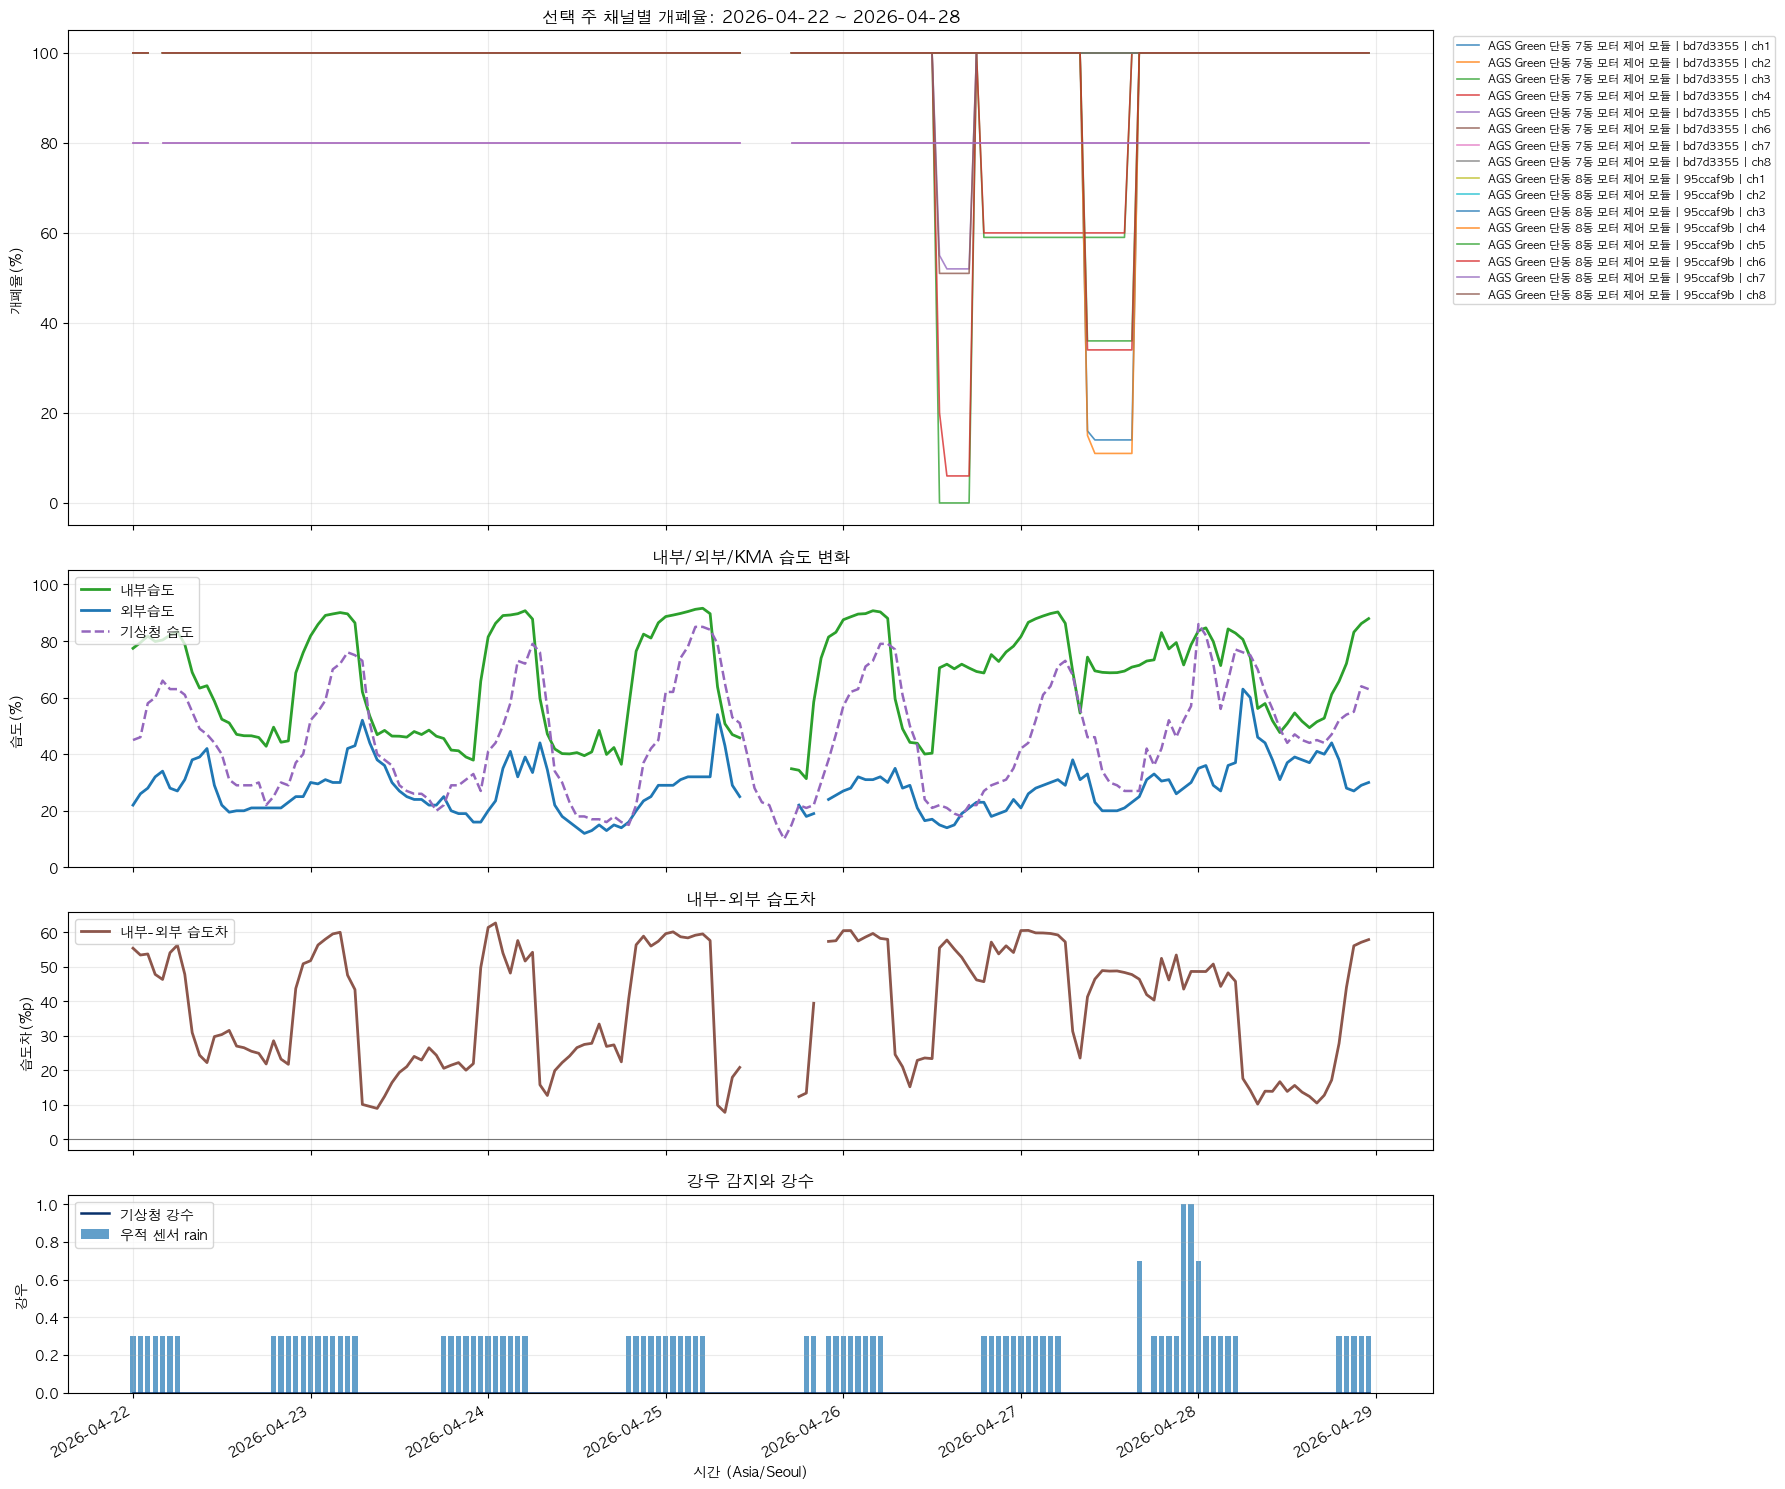

## 습도 동시 상관관계 상위 항목

,motor_channel,humidity_variable,n,pearson,spearman,open_rate_change_vs_humidity_change_pearson,abs_pearson
14,AGS Green 단동 7동 모터 제어 모듈 | bd7d3355 | ch4,humidity_gap,159,-0.303337,-0.309468,0.136392,0.303337
10,AGS Green 단동 7동 모터 제어 모듈 | bd7d3355 | ch3,humidity_gap,159,-0.300197,-0.309509,0.153522,0.300197
9,AGS Green 단동 7동 모터 제어 모듈 | bd7d3355 | ch3,external_humidity,159,0.261568,0.242602,0.006662,0.261568
13,AGS Green 단동 7동 모터 제어 모듈 | bd7d3355 | ch4,external_humidity,159,0.258988,0.242502,0.008872,0.258988
19,AGS Green 단동 7동 모터 제어 모듈 | bd7d3355 | ch5,kma_humidity,161,0.238180,0.256351,0.004758,0.238180
23,AGS Green 단동 7동 모터 제어 모듈 | bd7d3355 | ch6,kma_humidity,161,0.238073,0.256252,0.005503,0.238073
21,AGS Green 단동 7동 모터 제어 모듈 | bd7d3355 | ch6,external_humidity,159,0.224363,0.249086,-0.001072,0.224363
17,AGS Green 단동 7동 모터 제어 모듈 | bd7d3355 | ch5,external_humidity,159,0.223839,0.248865,-0.000423,0.223839
11,AGS Green 단동 7동 모터 제어 모듈 | bd7d3355 | ch3,kma_humidity,161,0.214330,0.152122,0.018033,0.214330
15,AGS Green 단동 7동 모터 제어 모듈 | bd7d3355 | ch4,kma_humidity,161,0.210283,0.152177,0.017452,0.210283


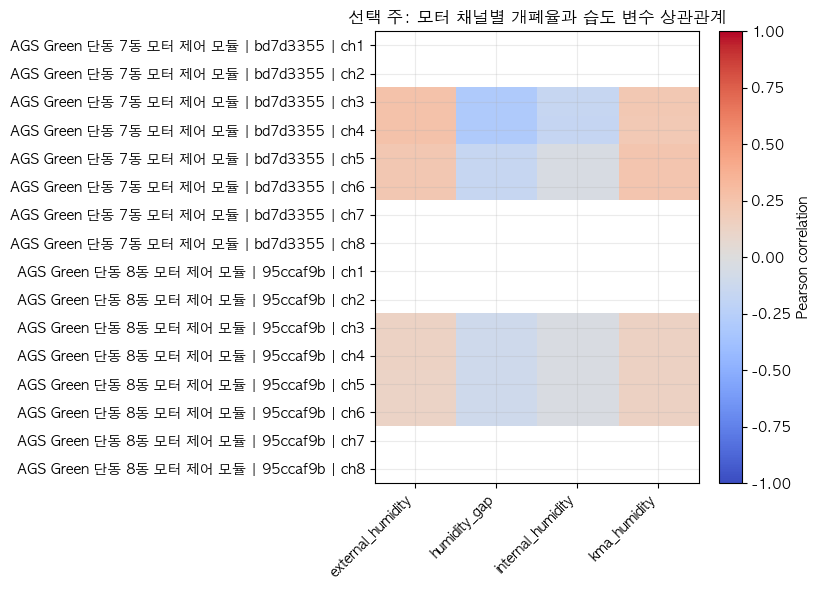

## 습도 시차상관 상위 항목

,motor_channel,humidity_variable,lag_hours,n,pearson,abs_pearson
282,AGS Green 단동 8동 모터 제어 모듈 | 95ccaf9b | ch5,humidity_gap,-24,129,0.325713,0.325713
326,AGS Green 단동 8동 모터 제어 모듈 | 95ccaf9b | ch6,humidity_gap,-24,129,0.325713,0.325713
194,AGS Green 단동 8동 모터 제어 모듈 | 95ccaf9b | ch3,humidity_gap,-24,129,0.325686,0.325686
238,AGS Green 단동 8동 모터 제어 모듈 | 95ccaf9b | ch4,humidity_gap,-24,129,0.325639,0.325639
1,AGS Green 단동 7동 모터 제어 모듈 | bd7d3355 | ch3,internal_humidity,-12,143,-0.315120,0.315120
45,AGS Green 단동 7동 모터 제어 모듈 | bd7d3355 | ch4,internal_humidity,-12,143,-0.315006,0.315006
23,AGS Green 단동 7동 모터 제어 모듈 | bd7d3355 | ch3,humidity_gap,-12,141,-0.312521,0.312521
67,AGS Green 단동 7동 모터 제어 모듈 | bd7d3355 | ch4,humidity_gap,-12,141,-0.311668,0.311668
71,AGS Green 단동 7동 모터 제어 모듈 | bd7d3355 | ch4,humidity_gap,0,159,-0.303337,0.303337
27,AGS Green 단동 7동 모터 제어 모듈 | bd7d3355 | ch3,humidity_gap,0,159,-0.300197,0.300197


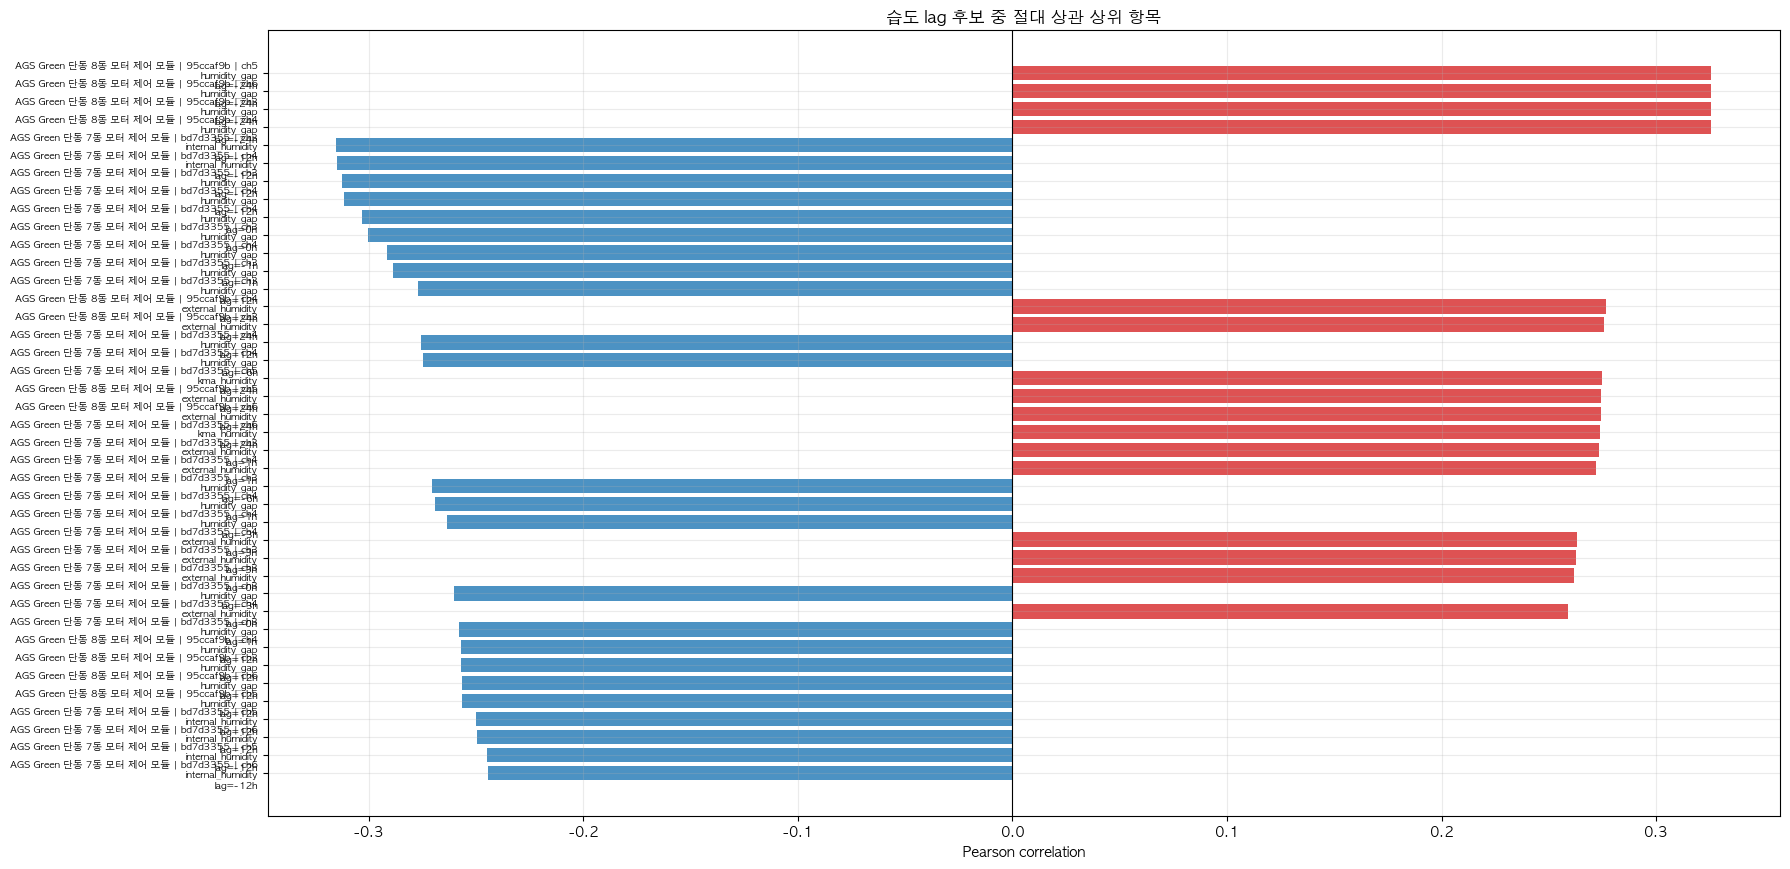

## 날짜별 습도 현상 요약

,date,max_open_rate,peak_open_rate_time,peak_open_rate_channel,active_channel_count,rain_sensor_hours,kma_rain_hours,internal_humidity_mean,internal_humidity_min,internal_humidity_max,...,external_humidity_range,humidity_gap_mean,humidity_gap_min,humidity_gap_max,humidity_gap_range,kma_humidity_mean,kma_humidity_min,kma_humidity_max,kma_humidity_range,phenomenon_note
0,2026-04-22,100.0,2026-04-22 00:00:00+09:00,AGS Green 단동 7동 모터 제어 모듈 | bd7d3355 | ch1,16,12,0,63.063542,42.800,83.325,...,22.5,36.584375,21.700,56.325,34.625,42.833333,22.0,66.0,44.0,"강우 동반 가능, 개별 채널 개폐율 높음, 하루 습도 변동 큼"
1,2026-04-23,100.0,2026-04-23 00:00:00+09:00,AGS Green 단동 7동 모터 제어 모듈 | bd7d3355 | ch1,16,13,0,59.276042,37.900,90.050,...,36.0,30.338542,8.900,60.050,51.150,42.500000,20.0,76.0,56.0,"강우 동반 가능, 고습도 구간 존재, 개별 채널 개폐율 높음, 하루 습도 변동 큼"
2,2026-04-24,100.0,2026-04-24 00:00:00+09:00,AGS Green 단동 7동 모터 제어 모듈 | bd7d3355 | ch1,16,11,0,63.085417,36.425,90.700,...,32.0,39.418750,12.650,62.750,50.100,38.208333,15.0,79.0,64.0,"강우 동반 가능, 고습도 구간 존재, 개별 채널 개폐율 높음, 하루 습도 변동 큼"
3,2026-04-25,100.0,2026-04-25 00:00:00+09:00,AGS Green 단동 7동 모터 제어 모듈 | bd7d3355 | ch1,16,10,0,68.619444,31.350,91.575,...,36.0,40.614063,7.750,60.175,52.425,46.291667,10.0,85.0,75.0,"강우 동반 가능, 고습도 구간 존재, 개별 채널 개폐율 높음, 하루 습도 변동 큼"
4,2026-04-26,100.0,2026-04-26 00:00:00+09:00,AGS Green 단동 7동 모터 제어 모듈 | bd7d3355 | ch1,16,11,0,70.673958,40.050,90.700,...,21.0,46.986458,15.175,60.550,45.375,43.166667,18.0,79.0,61.0,"강우 동반 가능, 고습도 구간 존재, 개별 채널 개폐율 높음, 하루 습도 변동 큼"
5,2026-04-27,100.0,2026-04-27 00:00:00+09:00,AGS Green 단동 7동 모터 제어 모듈 | bd7d3355 | ch1,16,13,0,76.370833,54.525,90.275,...,18.0,48.975000,23.525,60.600,37.075,46.833333,27.0,73.0,46.0,"강우 동반 가능, 고습도 구간 존재, 개별 채널 개폐율 높음, 하루 습도 변동 큼"
6,2026-04-28,100.0,2026-04-28 00:00:00+09:00,AGS Green 단동 7동 모터 제어 모듈 | bd7d3355 | ch1,16,11,0,67.565625,47.650,87.925,...,36.0,29.648958,10.150,57.925,47.775,59.625000,44.0,86.0,42.0,"강우 동반 가능, 개별 채널 개폐율 높음, 하루 습도 변동 큼"


## 높은 개폐율 시간대의 습도 상태

,motor_channel,threshold,high_open_hours,mean_open_rate_when_high,internal_humidity_mean_when_high,external_humidity_mean_when_high,humidity_gap_mean_when_high,kma_humidity_mean_when_high
0,AGS Green 단동 7동 모터 제어 모듈 | bd7d3355 | ch1,60.0,161,100.000000,66.808540,28.166667,38.797799,46.391304
1,AGS Green 단동 7동 모터 제어 모듈 | bd7d3355 | ch2,60.0,161,100.000000,66.808540,28.166667,38.797799,46.391304
6,AGS Green 단동 7동 모터 제어 모듈 | bd7d3355 | ch7,60.0,161,80.000000,66.808540,28.166667,38.797799,46.391304
7,AGS Green 단동 7동 모터 제어 모듈 | bd7d3355 | ch8,60.0,161,100.000000,66.808540,28.166667,38.797799,46.391304
15,AGS Green 단동 8동 모터 제어 모듈 | 95ccaf9b | ch8,60.0,161,100.000000,66.808540,28.166667,38.797799,46.391304
14,AGS Green 단동 8동 모터 제어 모듈 | 95ccaf9b | ch7,60.0,161,80.000000,66.808540,28.166667,38.797799,46.391304
9,AGS Green 단동 8동 모터 제어 모듈 | 95ccaf9b | ch2,60.0,161,100.000000,66.808540,28.166667,38.797799,46.391304
8,AGS Green 단동 8동 모터 제어 모듈 | 95ccaf9b | ch1,60.0,161,100.000000,66.808540,28.166667,38.797799,46.391304
3,AGS Green 단동 7동 모터 제어 모듈 | bd7d3355 | ch4,60.0,156,94.871795,66.675801,28.535714,38.299351,47.224359
4,AGS Green 단동 7동 모터 제어 모듈 | bd7d3355 | ch5,60.0,156,100.000000,66.675801,28.535714,38.299351,47.224359


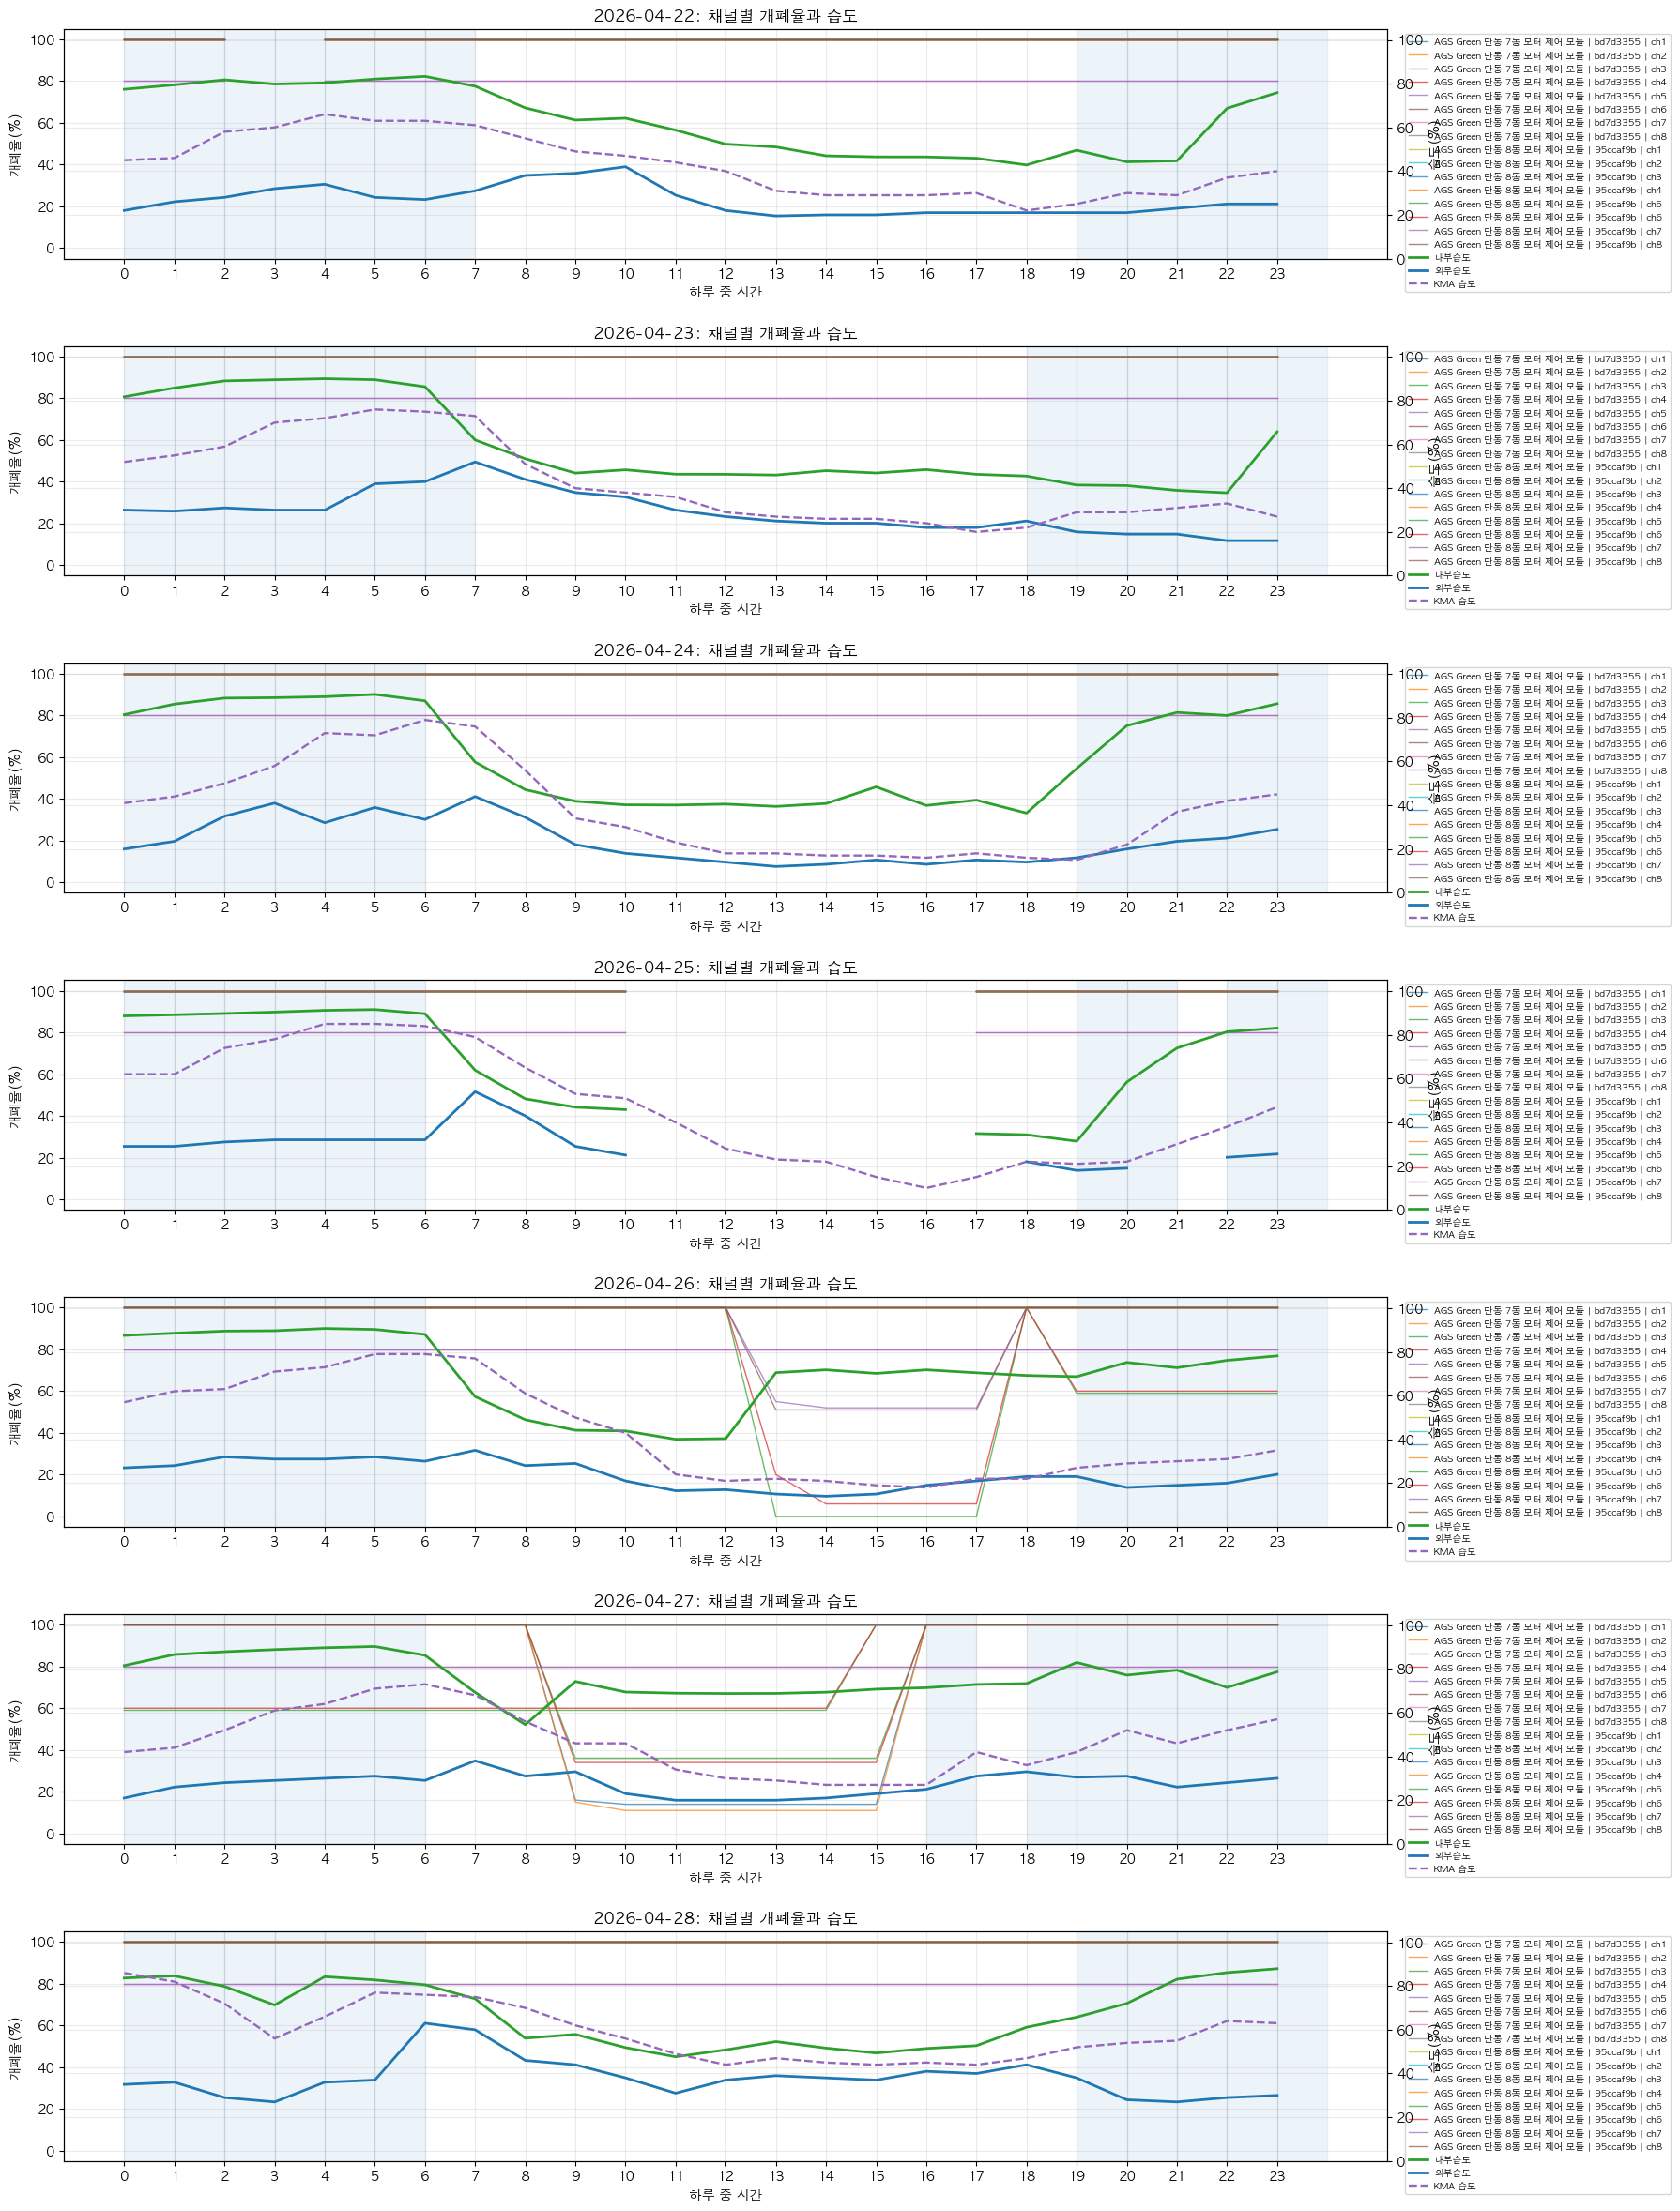

In [26]:
week_result = analyze_week_humidity(
    week_index=SELECTED_WEEK_INDEX,
    week_start_date=SELECTED_WEEK_START_DATE,
    save_outputs=SAVE_WEEK_OUTPUTS,
)

## 7. 선택 위젯으로 주 변경하기

`ipywidgets`가 설치되어 있으면 드롭다운으로 주를 선택할 수 있다. 위젯이 동작하지 않으면 설정 셀의 변수를 직접 바꾸면 된다.

In [27]:
try:
    import ipywidgets as widgets

    week_options = [
        (f"{int(row.week_index):02d}: {row.week_start:%Y-%m-%d} ~ {row.week_end:%Y-%m-%d}", int(row.week_index))
        for row in week_table.itertuples(index=False)
    ]
    dropdown = widgets.Dropdown(options=week_options, value=SELECTED_WEEK_INDEX, description="주 선택")
    button = widgets.Button(description="습도 연관도 분석 실행", button_style="primary")
    output = widgets.Output()

    def run_selected_week(_):
        with output:
            clear_output(wait=True)
            analyze_week_humidity(week_index=dropdown.value, save_outputs=SAVE_WEEK_OUTPUTS)

    button.on_click(run_selected_week)
    display(widgets.HBox([dropdown, button]))
    display(output)
except Exception as exc:
    display(Markdown(f"ipywidgets를 사용할 수 없어 변수 설정 방식으로 사용한다: `{exc}`"))

ipywidgets를 사용할 수 없어 변수 설정 방식으로 사용한다: `No module named 'ipywidgets'`

## 8. 결과 파일 구조

출력 폴더:

`data_inspect/output/weekly_motor_humidity_analysis_260211-260511/`

공통 파일:

- `aligned_hourly_humidity.csv`
- `humidity_hourly_long.csv`
- `available_weeks.csv`

선택 주별 파일:

- `week_aligned_hourly_humidity.csv`
- `week_humidity_correlations.csv`
- `week_humidity_lag_correlations.csv`
- `week_daily_humidity_summary.csv`
- `week_high_open_humidity_context.csv`
- `week_open_rate_humidity_overview.png`
- `week_humidity_correlation_heatmap.png`
- `week_humidity_lag_top.png`
- `daily_open_rate_humidity_profiles.png`

## 해석 시 주의사항

- 상관계수는 인과관계가 아니다.
- `lag_hours < 0`은 습도 변화가 개폐율보다 먼저 나타나는 후보로 해석한다.
- `lag_hours > 0`은 개폐율 변화 이후 습도 변화가 따라오는 후보로 해석한다.
- 습도는 강우와 온도에 강하게 영향을 받으므로, 강우 시간과 온도도 함께 확인해야 한다.